# Monte Carlo Dropout with Your Trained Model

In [59]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Trained Model

In [60]:
# Path where you saved the trained model
# model_path = "/content/drive/MyDrive/pneumonia_project/vgg19_model_colab.h5"
model_path = "/content/drive/MyDrive/pneumonia_project/vgg19_final_model_colab.h5"

# Custom loss required to load the model if Focal Loss was used
from tensorflow.keras import backend as K
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss

model = tf.keras.models.load_model(model_path, custom_objects={'loss': focal_loss()})

## Load an Image

In [61]:
def load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

## Monte Carlo Dropout Prediction Function

In [62]:
def predict_with_uncertainty(model, img_array, n_iter=100):
    predictions = np.array([model(img_array, training=True).numpy()[0] for _ in range(n_iter)])
    mean_pred = np.mean(predictions, axis=0)
    std_pred = np.std(predictions, axis=0)
    return mean_pred, std_pred, predictions


## Run the Prediction

In [63]:
# Example image path
image_path = "/content/drive/MyDrive/Curated X-Ray Dataset/COVID-19/COVID-19 (1010).jpg"
img_array = load_image(image_path)

# mean_pred, std_pred, all_preds = predict_with_uncertainty(model, img_array)

# class_names = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

# # Print mean + uncertainty
# for i, c in enumerate(class_names):
#     print(f"{c}: {mean_pred[i]*100:.2f}% ± {std_pred[i]*100:.2f}%")



🔍 Prediction Probabilities:
COVID-19: 96.72% ± 16.55%
Normal: 3.28% ± 16.55%
Pneumonia-Bacterial: 0.00% ± 0.00%
Pneumonia-Viral: 0.00% ± 0.00%


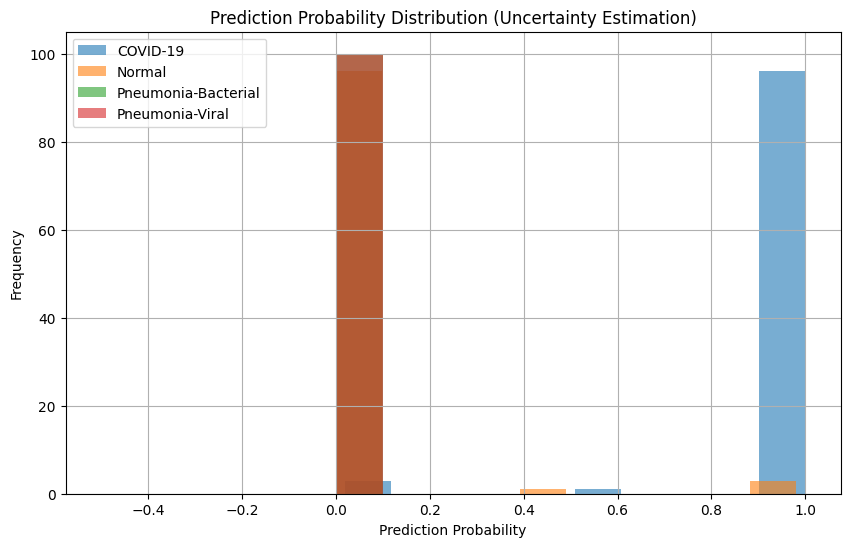

✅ Uncertainty plot saved as uncertainty_plot.png


<Figure size 640x480 with 0 Axes>

In [64]:
# After getting predictions using MC Dropout
mean_pred, std_pred, all_preds = predict_with_uncertainty(model, img_array)

# Print mean prediction and uncertainty
print("\n🔍 Prediction Probabilities:")
for i, cls in enumerate(class_names):
    print(f"{cls}: {mean_pred[i]*100:.2f}% ± {std_pred[i]*100:.2f}%")


import matplotlib.pyplot as plt

# Define plot function
def plot_prediction_distribution(predictions, class_names):
    plt.figure(figsize=(10, 6))
    for i in range(predictions.shape[1]):
        plt.hist(predictions[:, i], bins=10, alpha=0.6, label=class_names[i])
    plt.title('Prediction Probability Distribution (Uncertainty Estimation)')
    plt.xlabel('Prediction Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

# Class names
class_names = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

# Call plot function
plot_prediction_distribution(all_preds, class_names)

# Save the figure
plt.savefig('/content/drive/MyDrive/pneumonia_project/uncertainty_plot.png')
print("✅ Uncertainty plot saved as uncertainty_plot.png")
